# Prophet Forecasting Playground

This notebook provides an interactive environment to test the cluster-based Prophet model in two different operational modes:
1. **Long-Term Forecast**: Relies solely on seasonal trends, holiday effects, and calendar features. Used for capacity planning.
2. **Day-Ahead Forecast**: Enriched with historical consumption lags (e.g., 24h and 1-week back). Used for short-term operational dispatching.

### Key Features
- **Dual-Mode Pipeline**: Test how adding consumption lags dramatically improves short-term accuracy.
- **Modular Architecture**: Uses decoupled functions from `src/models/prophet_model.py` for preprocessing, training, and inference.
- **Zero Data Leakage**: Scaling is strictly fitted on training data (< 2014).

## 0. Environment Setup

Resolve project-level modules from the `src` directory and load the necessary forecasting functions.

In [12]:
%load_ext autoreload
%autoreload 2

import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure project root is in path
PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Import specialized Prophet functions from correctly named module
from src.models.prophet_model import (
    load_processed_data, 
    preprocess_and_split, 
    train_models, 
    predict_models, 
    evaluate_models,
    save_prophet_artifacts
)
from src.tools.visualization import plot_cluster_portfolio, analyze_time_periods

print("Setup complete. Local prophet modules loaded from src/.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Setup complete. Local prophet modules loaded from src/.


## 1. Global Data Loading

We load the global processed dataset once. It contains all features, including the raw consumption and weather signals that will be scaled differently depending on the forecast mode.

In [13]:
dataset_path = os.path.join(PROJECT_ROOT, 'Datasets', 'processed_electricity_data.parquet')
df_long = load_processed_data(dataset_path)

print(f"\n Total observations loaded: {len(df_long):,}")

Loading processed data...

 Total observations loaded: 41,548,234


## 2. Long-Term Horizon

In this mode, the model does NOT see the recent consumption lags. It learns to predict the load based strictly on the time of day, day of week, holidays, and external weather regressors.

In [14]:
# A.1 Prepare Data (Long Term)
train_agg_lt, test_agg_lt, test_raw_lt, scalers_lt, sw_lt, regs_lt = preprocess_and_split(df_long, mode='long_term')

# A.2 Train Cluster Models
models_lt = train_models(train_agg_lt, regs_lt)

# A.3 Predict & Un-scale
results_lt = predict_models(models_lt, test_agg_lt, test_raw_lt, scalers_lt, regs_lt)

# A.4 Evaluate
eval_lt, summary_lt = evaluate_models(results_lt)
display(summary_lt)

Preparing train/test split and scaling (Mode: LONG_TERM)...
Scaling individual clients...


Scaling Clients: 100%|██████████| 369/369 [00:06<00:00, 54.96it/s]


Aggregating data by Cluster for Prophet training...
Training Prophet models for 5 clusters...


Training:   0%|          | 0/5 [00:00<?, ?it/s]19:49:00 - cmdstanpy - INFO - Chain [1] start processing
19:49:17 - cmdstanpy - INFO - Chain [1] done processing
Training:  20%|██        | 1/5 [00:19<01:17, 19.44s/it]19:49:21 - cmdstanpy - INFO - Chain [1] start processing
19:50:00 - cmdstanpy - INFO - Chain [1] done processing
Training:  40%|████      | 2/5 [01:02<01:40, 33.43s/it]19:50:04 - cmdstanpy - INFO - Chain [1] start processing
19:51:00 - cmdstanpy - INFO - Chain [1] done processing
Training:  60%|██████    | 3/5 [02:02<01:30, 45.34s/it]19:51:04 - cmdstanpy - INFO - Chain [1] start processing
19:51:53 - cmdstanpy - INFO - Chain [1] done processing
Training:  80%|████████  | 4/5 [02:55<00:48, 48.36s/it]19:51:57 - cmdstanpy - INFO - Chain [1] start processing
19:52:37 - cmdstanpy - INFO - Chain [1] done processing
Training: 100%|██████████| 5/5 [03:39<00:00, 43.87s/it]


Generating forecasts and un-scaling to raw kW...


Un-scaling Clients: 100%|██████████| 369/369 [00:04<00:00, 82.24it/s] 



Evaluating Portfolio Performance...


,Portfolio_MAPE,Portfolio_WMAPE
Cluster,,
Global,75.54,19.79
0.0,40.67,13.95
1.0,74.14,21.92
2.0,232.17,33.21
3.0,18.12,15.48
4.0,12.62,10.25


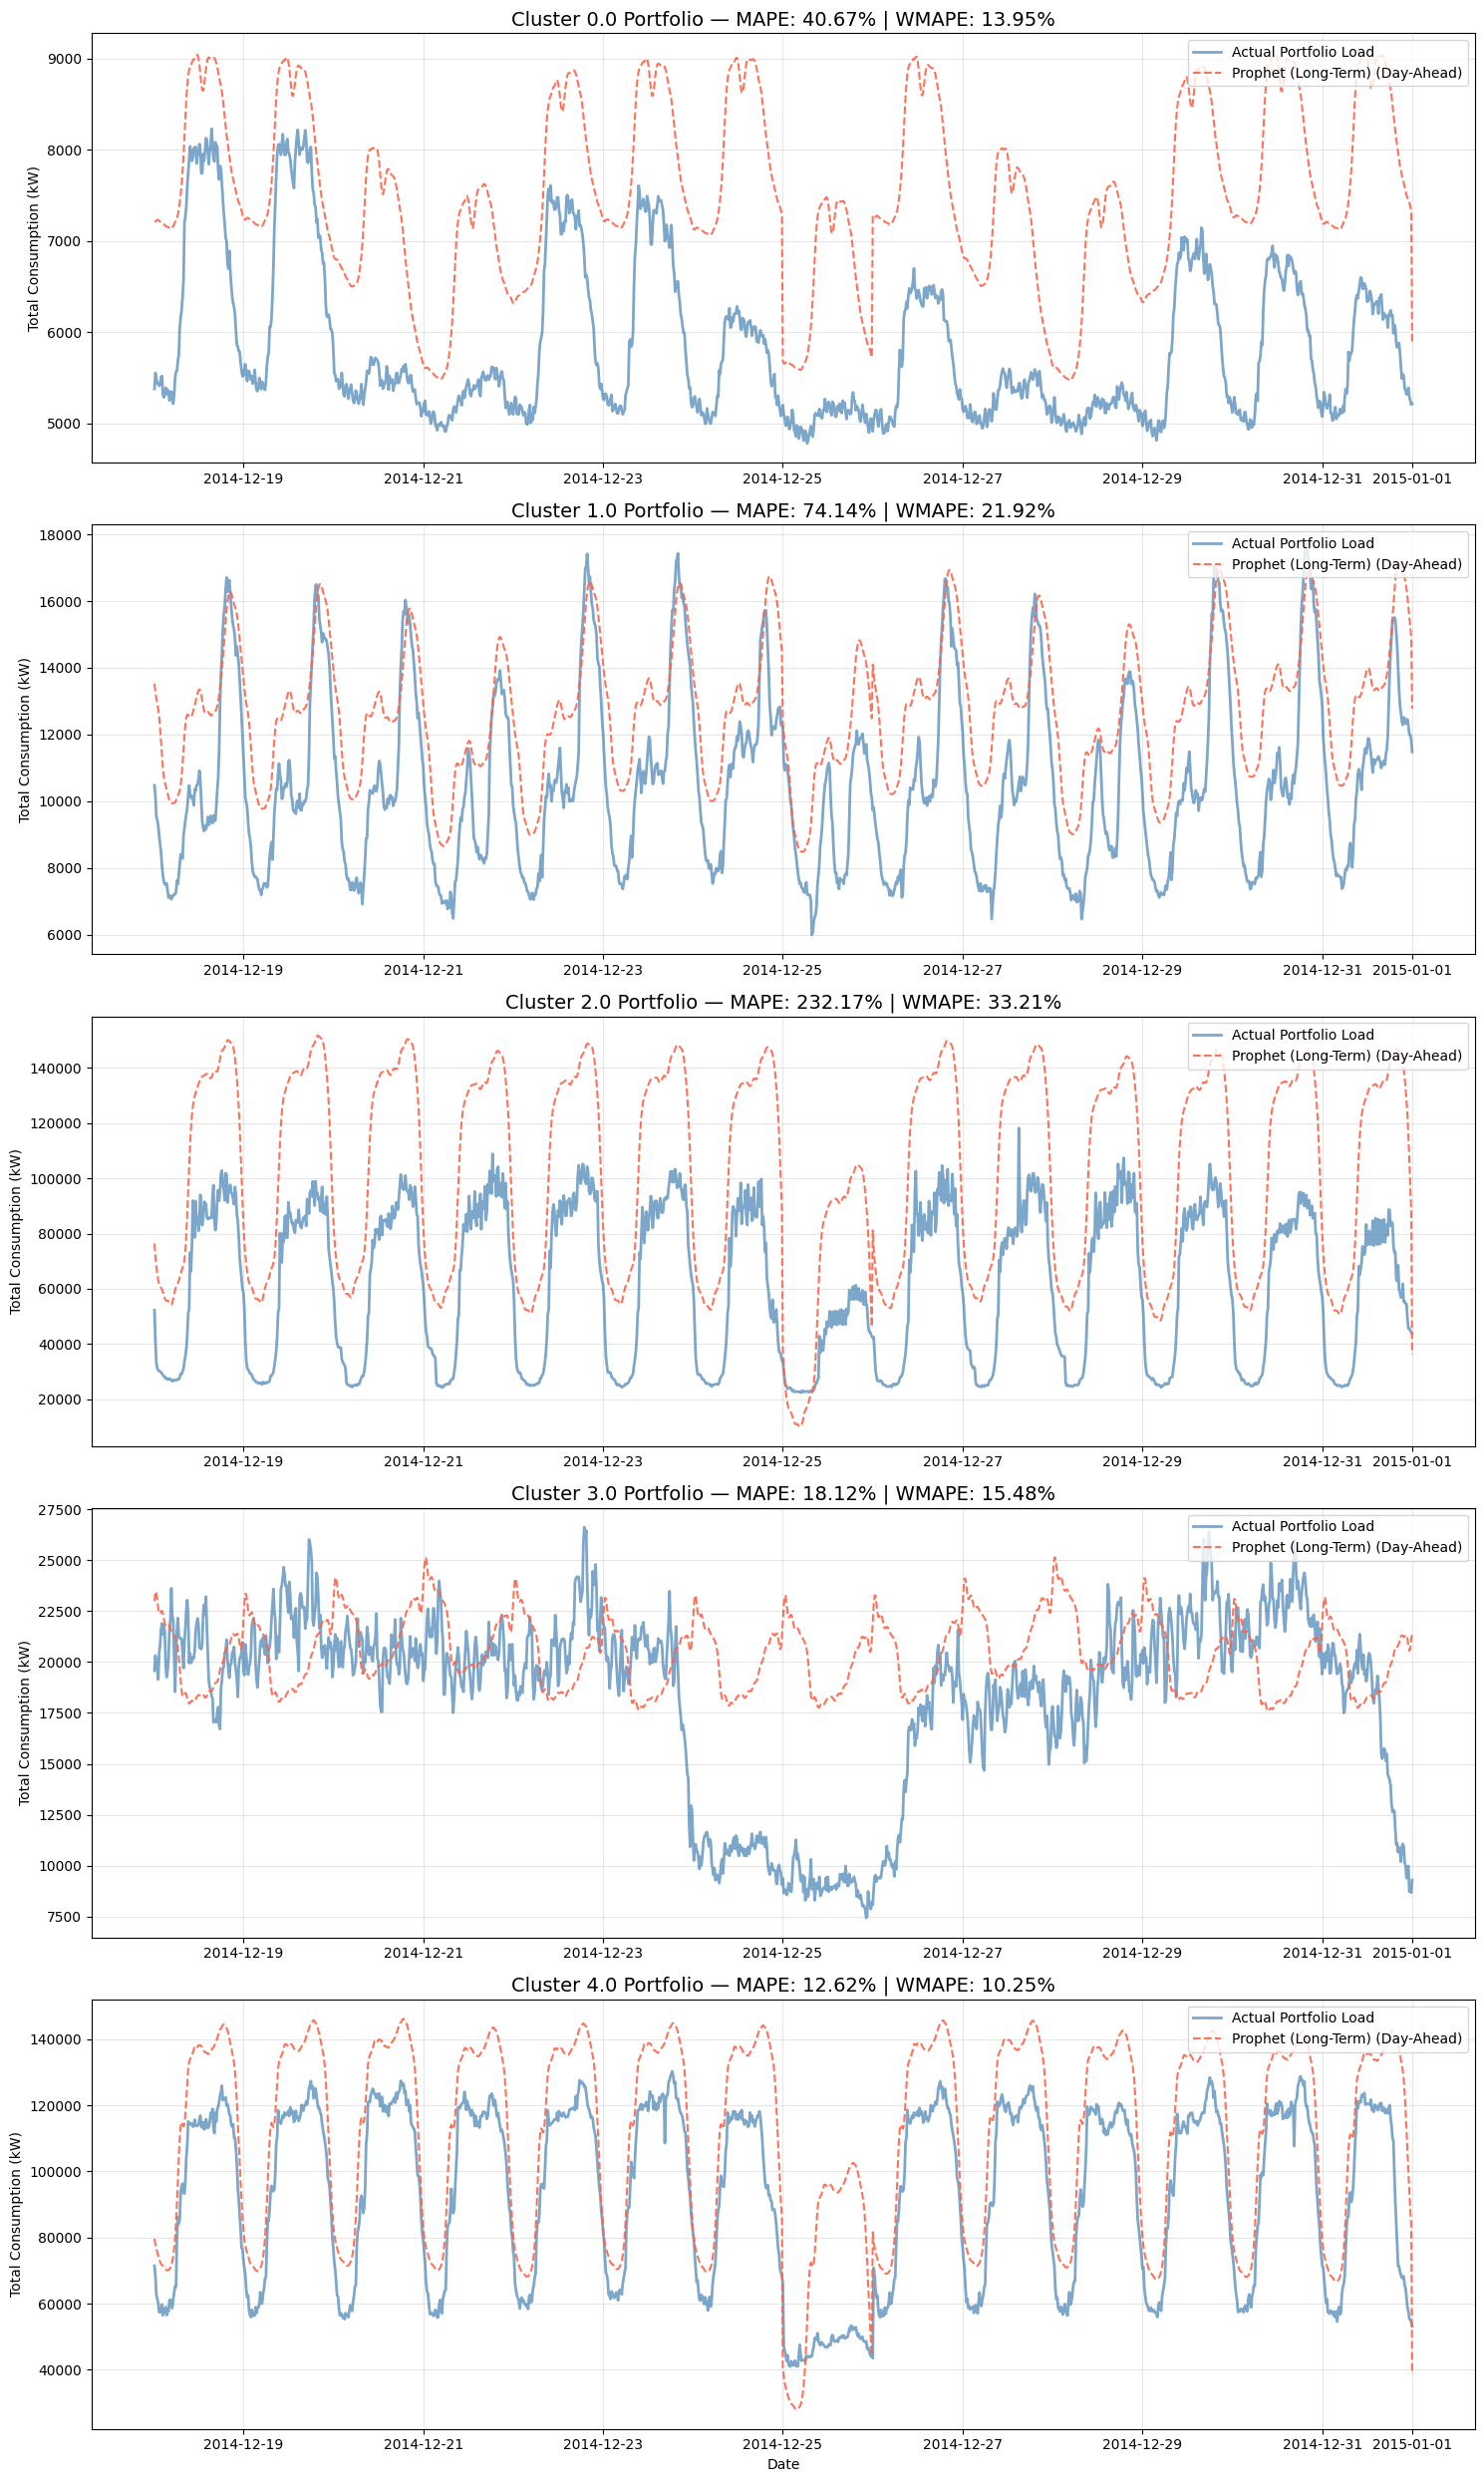

In [15]:
# Visualization for Long-Term results
plot_cluster_portfolio(eval_lt, summary_lt, model_label="Prophet (Long-Term)")

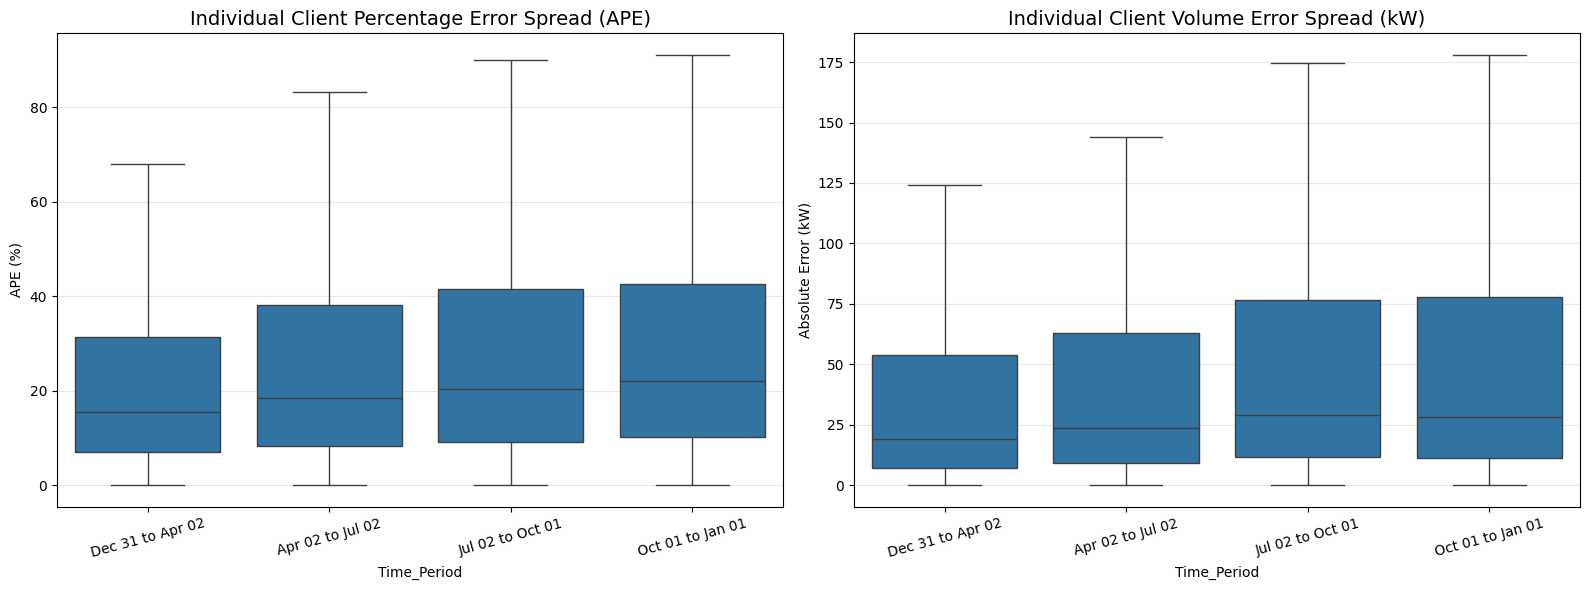

,MAPE,WMAPE
Time_Period,,
Dec 31 to Apr 02,48.80,22.73
Apr 02 to Jul 02,52.42,23.35
Jul 02 to Oct 01,54.26,21.91
Oct 01 to Jan 01,50.57,31.50


In [16]:
# Perform time-period split analysis
summary_lt = analyze_time_periods(results_lt)
display(summary_lt)

## 3. Day-Ahead Horizon

In this mode, we provide Prophet with the consumption from 24h ago and 1 week ago. This allows the model to capture the "inertia" of the load, which is critical for precise day-ahead forecasts.

In [17]:
# B.1 Prepare Data (Day Ahead)
train_agg_da, test_agg_da, test_raw_da, scalers_da, sw_da, regs_da = preprocess_and_split(df_long, mode='day_ahead')

# B.2 Train Cluster Models
models_da = train_models(train_agg_da, regs_da)

# B.3 Predict & Un-scale
results_da = predict_models(models_da, test_agg_da, test_raw_da, scalers_da, regs_da)

# B.4 Evaluate
eval_da, summary_da = evaluate_models(results_da)
display(summary_da)

Preparing train/test split and scaling (Mode: DAY_AHEAD)...
Scaling individual clients...


Scaling Clients: 100%|██████████| 369/369 [00:18<00:00, 19.93it/s]


Aggregating data by Cluster for Prophet training...
Training Prophet models for 5 clusters...


Training:   0%|          | 0/5 [00:00<?, ?it/s]19:53:23 - cmdstanpy - INFO - Chain [1] start processing
19:53:49 - cmdstanpy - INFO - Chain [1] done processing
Training:  20%|██        | 1/5 [00:28<01:53, 28.27s/it]19:53:53 - cmdstanpy - INFO - Chain [1] start processing
19:54:32 - cmdstanpy - INFO - Chain [1] done processing
Training:  40%|████      | 2/5 [01:11<01:51, 37.09s/it]19:54:37 - cmdstanpy - INFO - Chain [1] start processing
19:55:22 - cmdstanpy - INFO - Chain [1] done processing
Training:  60%|██████    | 3/5 [02:01<01:26, 43.09s/it]19:55:27 - cmdstanpy - INFO - Chain [1] start processing
19:55:59 - cmdstanpy - INFO - Chain [1] done processing
Training:  80%|████████  | 4/5 [02:38<00:40, 40.67s/it]19:56:04 - cmdstanpy - INFO - Chain [1] start processing
19:56:51 - cmdstanpy - INFO - Chain [1] done processing
Training: 100%|██████████| 5/5 [03:30<00:00, 42.18s/it]


Generating forecasts and un-scaling to raw kW...


Un-scaling Clients: 100%|██████████| 369/369 [00:04<00:00, 78.76it/s] 



Evaluating Portfolio Performance...


,Portfolio_MAPE,Portfolio_WMAPE
Cluster,,
Global,58.04,10.49
0.0,32.07,5.55
1.0,62.79,13.84
2.0,171.39,17.30
3.0,17.52,14.80
4.0,6.42,4.32


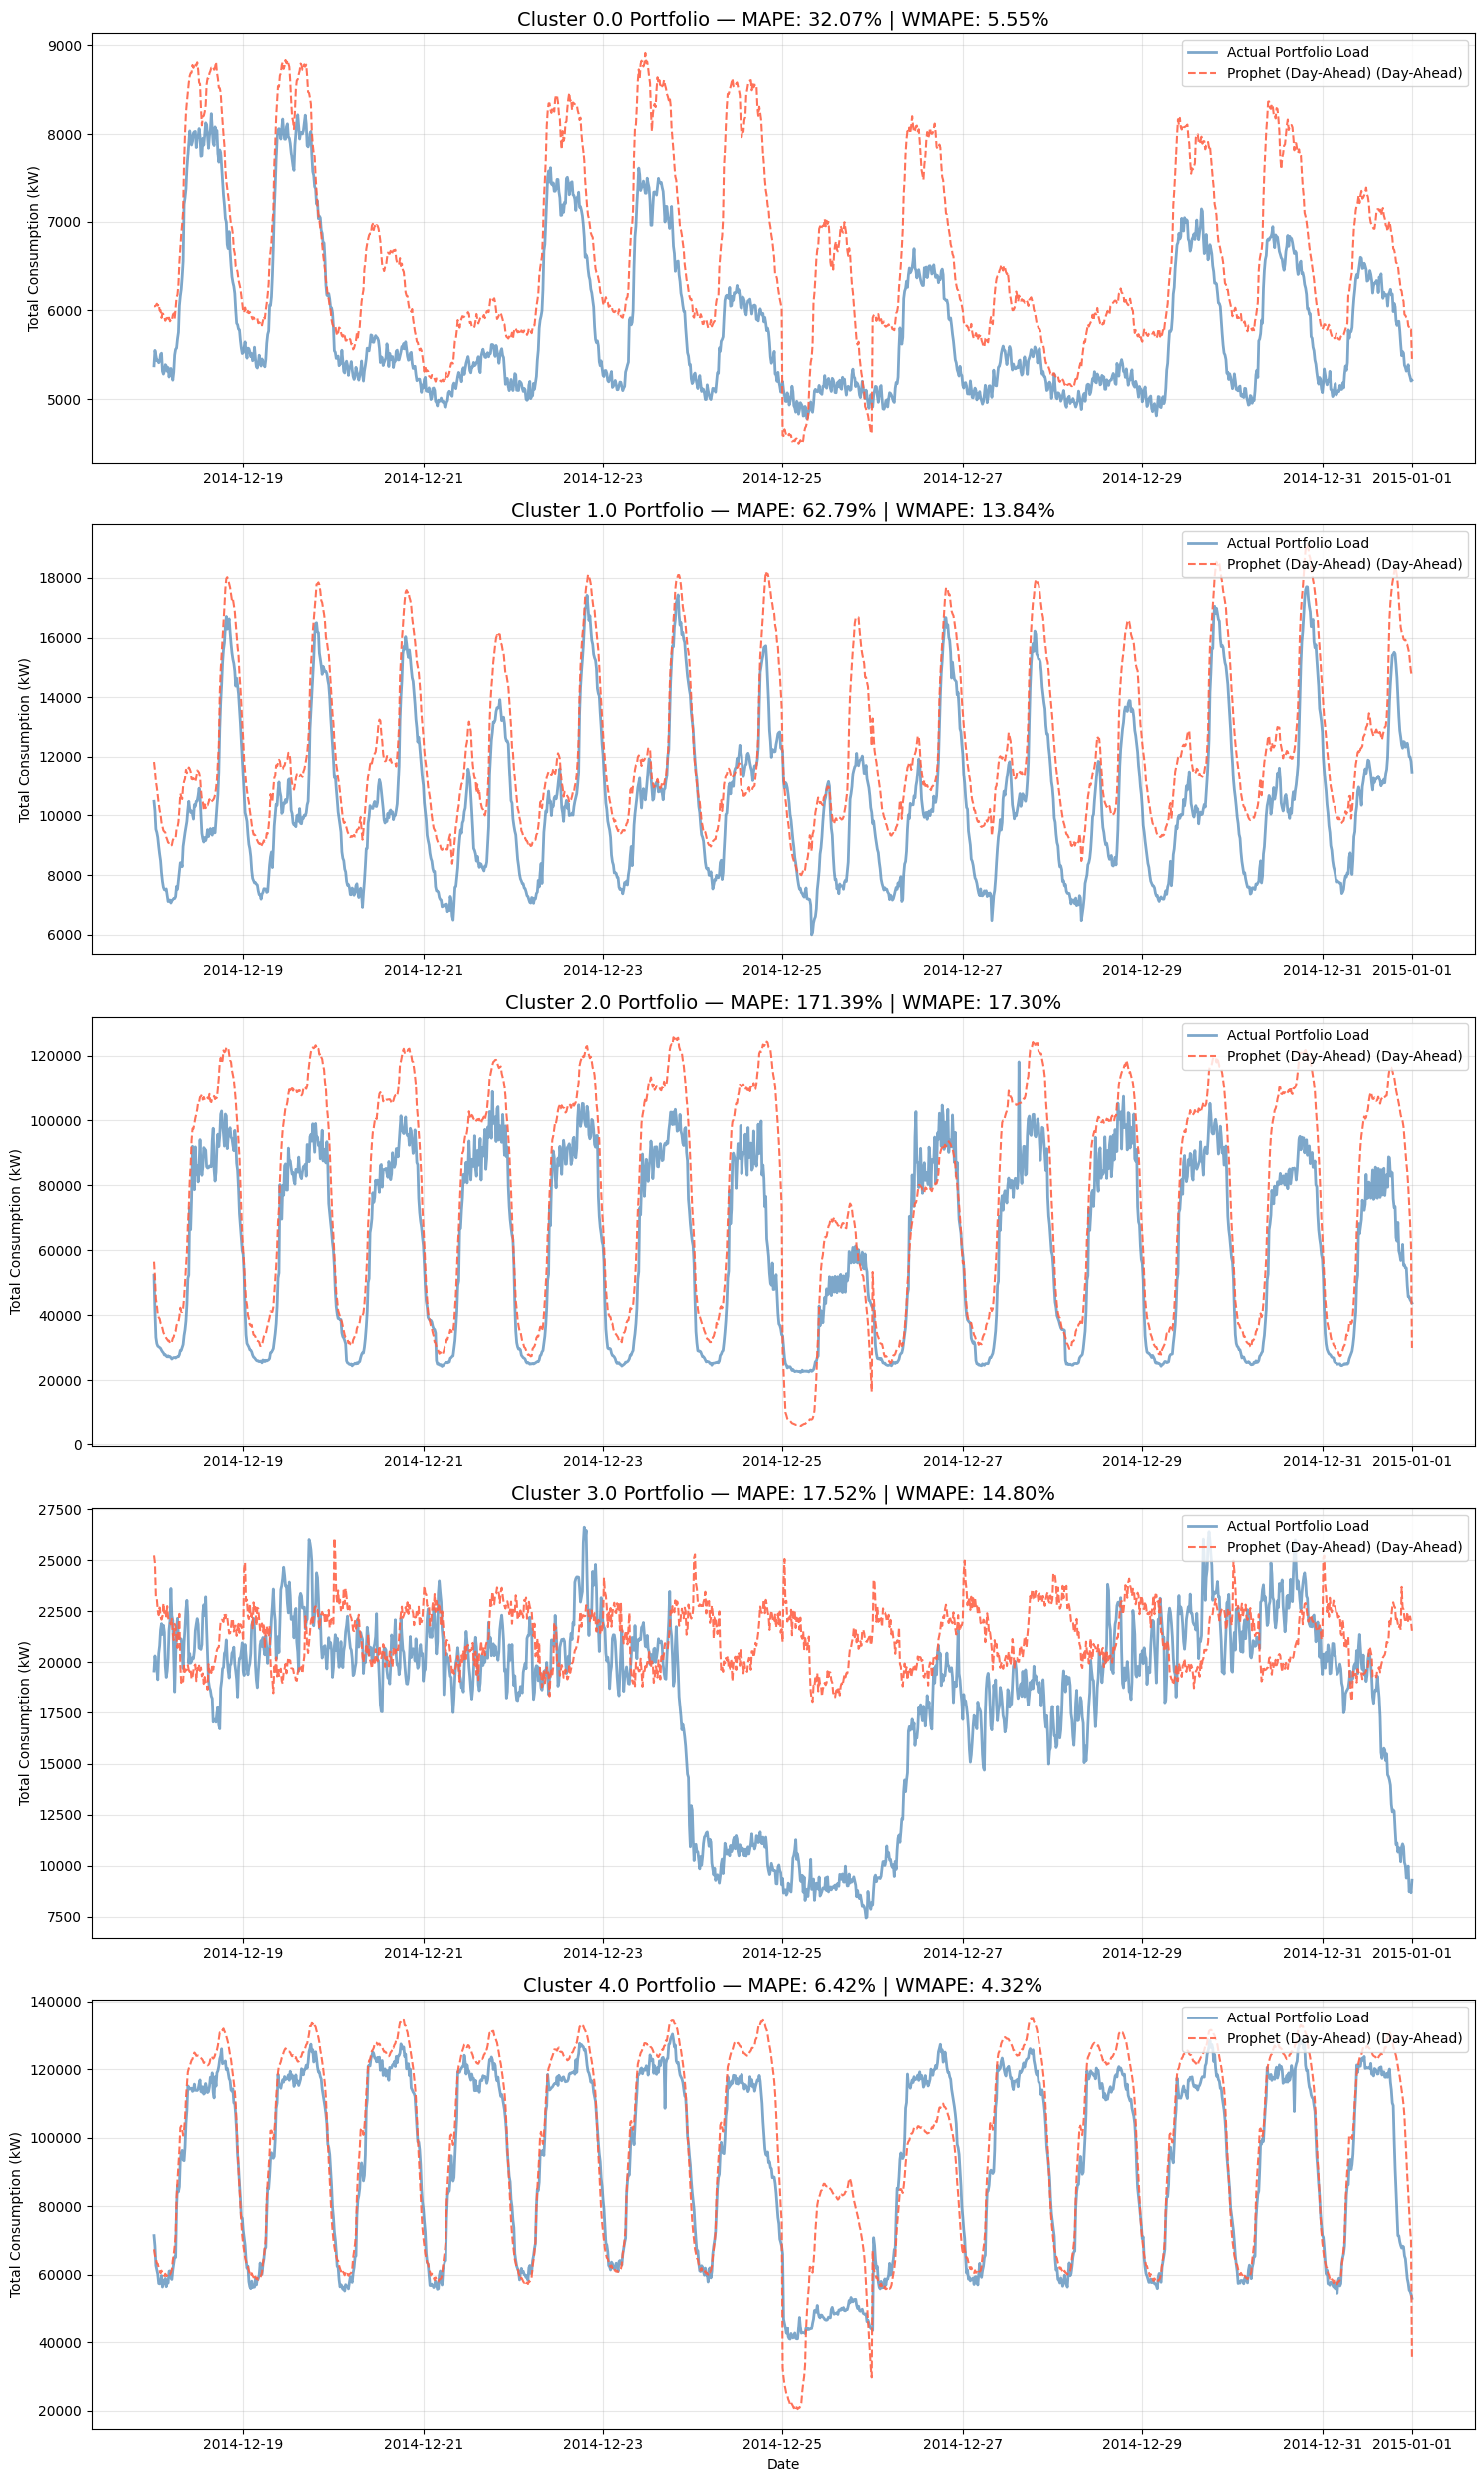

In [18]:
# Visualization for Day-Ahead results
plot_cluster_portfolio(eval_da, summary_da, model_label="Prophet (Day-Ahead)")

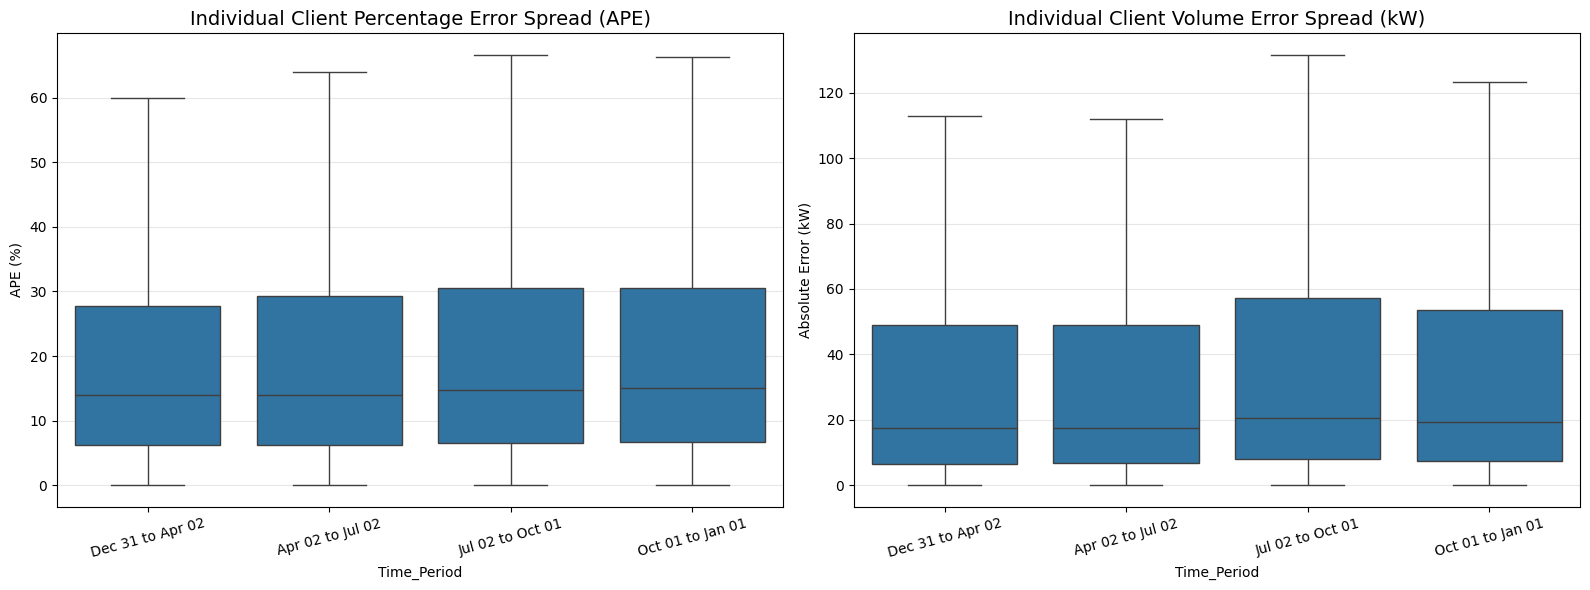

,MAPE,WMAPE
Time_Period,,
Dec 31 to Apr 02,44.96,18.23
Apr 02 to Jul 02,39.22,15.62
Jul 02 to Oct 01,37.11,17.60
Oct 01 to Jan 01,34.07,18.41


In [19]:
# Perform time-period split analysis
summary_da = analyze_time_periods(results_da)
display(summary_da)